# Classificação Supervisionada com Agglomerative Clustering no Dataset Adult (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Adult balanceado por oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e implementação do Agglomerative Clustering.

In [1]:
# Importação das bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import seaborn as sns
import os
os.makedirs('img', exist_ok=True)

## 2. Carregamento, Balanceamento e Pré-processamento dos Dados

Carregamos o dataset Adult, removemos valores ausentes, balanceamos as classes por oversampling, codificamos variáveis categóricas e normalizamos os dados.

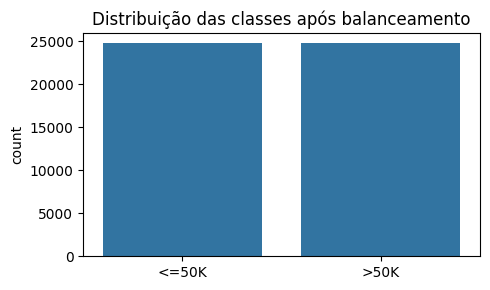

In [2]:
# Carregamento do dataset Adult
adult_df_raw = pd.read_csv('data/AdultDataset/adult.data', header=None, na_values=' ?', skipinitialspace=True)
adult_df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]
# Remover valores ausentes
df = adult_df_raw.dropna().copy()
# Criar coluna binária: 1 para renda >50K, 0 para renda <=50K
df['income_bin'] = df['income'].apply(lambda v: 1 if v.strip() == '>50K' else 0)
# Balanceamento por oversampling
df_majority = df[df['income_bin'] == 0]
df_minority = df[df['income_bin'] == 1]
n_majority = len(df_majority)
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=n_majority,
    random_state=42
)
df_bal = pd.concat([df_majority, df_minority_upsampled])
df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)
# Separar features e target
X = df_bal.drop(['income', 'income_bin'], axis=1)
y = df_bal['income_bin'].values
# Codificação de variáveis categóricas
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
# Normalização
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
# Visualização do balanceamento
plt.figure(figsize=(5,3))
sns.countplot(x=y)
plt.title('Distribuição das classes após balanceamento')
plt.xticks([0,1],["<=50K",">50K"])
plt.tight_layout()
plt.savefig('img/agglo_adult_balance_dist.png')
plt.show()

## 3. Divisão dos Dados em Treino e Teste

Dividimos o conjunto de dados em 70% para treinamento e 30% para teste, garantindo a estratificação das classes.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.3, random_state=42, stratify=y)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (34608, 14), Teste: (14832, 14)


In [4]:
n_clusters = 2  # Ajuste conforme o dendrograma

## 4. Implementação do Classificador Agglomerative Supervisionado

O classificador associa cada cluster ao rótulo mais frequente no conjunto de treino.

In [5]:
class AggloSupervisionado:
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 5. Treinamento e Avaliação do Classificador

Treinamos o classificador no conjunto de treino e avaliamos no conjunto de teste, mostrando acurácia e matriz de confusão.

Acurácia: 0.6988
Matriz de Confusão:
[[5416 2000]
 [2468 4948]]


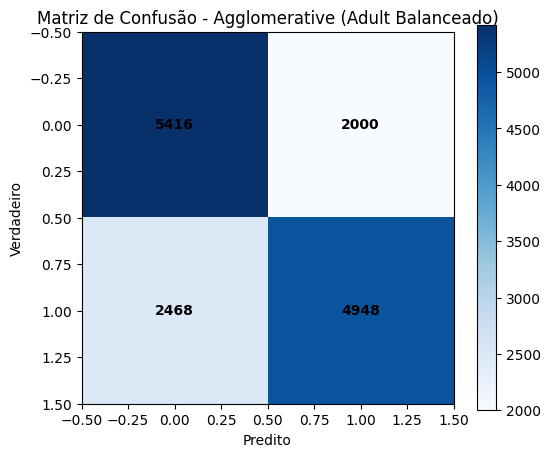

In [6]:

clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão - Agglomerative (Adult Balanceado)')
plt.colorbar()
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
# Adiciona os valores nas células
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/agglo_adult_balance_confusion_matrix.png')
plt.show()

## 6. Repetição dos Experimentos

Repita o experimento 30 vezes, variando a semente, e salve as acurácias e MSE para análise estatística.

Acurácia média: 0.6503
Desvio padrão da acurácia: 0.1218
MSE médio: 0.3497
Desvio padrão do MSE: 0.1218


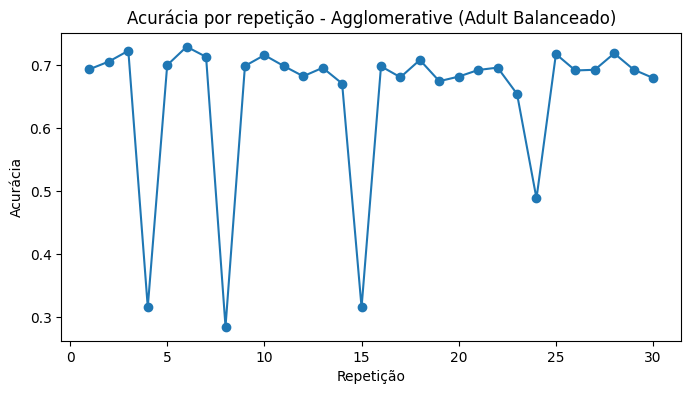

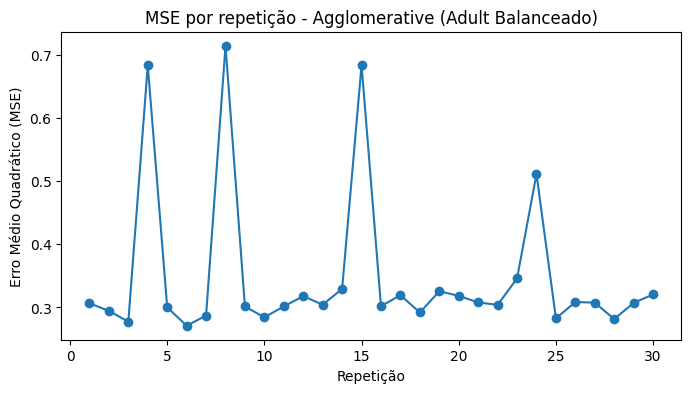

In [7]:
acuracias = []
mse_list = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    acuracias.append(acc)
    mse_list.append(mse)
acuracias = np.array(acuracias)
mse_array = np.array(mse_list)
print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print(f'MSE médio: {mse_array.mean():.4f}')
print(f'Desvio padrão do MSE: {mse_array.std():.4f}')
plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Adult Balanceado)')
plt.savefig('img/agglo_adult_balance_accuracy_repetitions.png')
plt.show()
plt.figure(figsize=(8,4))
plt.plot(range(1, 31), mse_array, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Erro Médio Quadrático (MSE)')
plt.title('MSE por repetição - Agglomerative (Adult Balanceado)')
plt.savefig('img/agglo_adult_balance_mse_repetitions.png')
plt.show()
np.save('img/agglo_adult_balance_accuracies.npy', acuracias)
np.savetxt('img/agglo_adult_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/agglo_adult_balance_mse_repetitions.npy', mse_array)
np.savetxt('img/agglo_adult_balance_mse_repetitions.csv', mse_array, delimiter=',')

## 7. Análise dos Resultados

Comente os resultados obtidos, destacando a acurácia média, o desvio padrão e possíveis dificuldades do classificador Agglomerative no dataset Adult balanceado. Compare com o cenário desbalanceado.

## 9. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Agglomerative no dataset Adult balanceado. As principais métricas (acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média) permitem avaliar o desempenho do modelo de forma quantitativa e qualitativa.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados.
- **Matriz de confusão média:** Permite visualizar como os clusters encontrados se relacionam com as classes reais, identificando acertos e erros do agrupamento.
- **Precisão, recall, especificidade e F1-score:** Complementam a análise, mostrando o comportamento do modelo em relação a cada classe.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- Padrões diagonais na matriz de confusão sugerem boa correspondência entre clusters e classes reais.
- Métricas equilibradas indicam que o balanceamento foi eficaz e o modelo não favorece uma classe específica.

**Sugestões:**
- Compare os resultados do Agglomerative com outros métodos (KMeans, Fuzzy C-Means, GK) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere a visualização dos agrupamentos (PCA) para interpretar a separação dos grupos no espaço de atributos.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Repetição dos experimentos para obter métricas médias
precisions = []
recalls = []
specificities = []
f1s = []
accuracies = []
cms = []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    cms.append(cm)
    # Especificidade: TN / (TN + FP)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print('Acurácia média:', np.mean(accuracies))
print('Precisão média:', np.mean(precisions))
print('Recall (Sensibilidade) médio:', np.mean(recalls))
print('Especificidade média:', np.mean(specificities))
print('F1-score médio:', np.mean(f1s))
print('Matriz de confusão média:')
print(np.mean(cms, axis=0))

## 8. Cálculo e Interpretação das Métricas de Avaliação

Nesta etapa, calculamos as principais métricas de avaliação para problemas binários:
- **Acurácia**: proporção de acertos totais.
- **Precisão**: entre os exemplos classificados como positivos, quantos realmente são positivos.
- **Recall (Sensibilidade)**: entre os exemplos realmente positivos, quantos foram corretamente identificados.
- **Especificidade**: entre os exemplos realmente negativos, quantos foram corretamente identificados.
- **F1-score**: média harmônica entre precisão e recall.
- **Matriz de confusão média**: média das matrizes de confusão das 30 execuções.

Essas métricas permitem avaliar o desempenho do classificador de forma mais completa, especialmente em cenários de classes desbalanceadas.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix3
import numpy as np
def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary')
    rec = recall_score(y_true, y_pred, average='binary')
    f1 = f1_score(y_true, y_pred, average='binary')
    cm = confusion_matrix(y_true, y_pred)
    # Especificidade: TN / (TN + FP)
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
        especificidade = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    else:
        especificidade = np.nan
    return acc, prec, rec, especificidade, f1, cm

# Repetição para obter métricas médias
accs, precs, recs, especificidades, f1s, cms = [], [], [], [], [], []
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc, prec, rec, esp, f1, cm = calcular_metricas(y_test, y_pred)
    accs.append(acc)
    precs.append(prec)
    recs.append(rec)
    especificidades.append(esp)
    f1s.append(f1)
    cms.append(cm)

print(f'Acurácia média: {np.mean(accs):.4f}')
print(f'Precisão média: {np.mean(precs):.4f}')
print(f'Recall médio: {np.mean(recs):.4f}')
print(f'Especificidade média: {np.mean(especificidades):.4f}')
print(f'F1-score médio: {np.mean(f1s):.4f}')
print('Matriz de confusão média:')
print(np.mean(cms, axis=0).round(2))

## 8. Cálculo das Principais Métricas de Avaliação
Nesta etapa, calculamos e exibimos as principais métricas de avaliação do classificador: acurácia, precisão, recall, especificidade, F1-score e matriz de confusão média. Essas métricas permitem uma análise quantitativa detalhada do desempenho do modelo.